# Mixed-Integer Quadratic Programming (MIQP)

A tutorial for first-year PhD students on formulating and solving mixed-integer quadratic programs.

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain how MIQP extends QP with integrality constraints
2. Formulate cardinality-constrained portfolio optimization as an MIQP
3. Model facility location problems with quadratic shipping costs
4. Understand how QP relaxations are solved at each node of the Branch-and-Bound tree
5. Analyze the trade-off between discrete decisions and quadratic objectives

**Prerequisites:** Basic optimization, familiarity with Python and NumPy. The LP, QP, and MILP tutorials in this series are helpful but not required.

**References:** This tutorial draws on the portfolio optimization framework of {cite:p}`Markowitz1952` and the integer programming foundations of {cite:p}`Wolsey1998`.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import numpy as np

## 1. What is MIQP?

A **Quadratic Program (QP)** minimizes a quadratic objective subject to linear constraints:

$$\min_{x} \; \tfrac{1}{2} x^\top Q x + c^\top x \quad \text{s.t.} \quad Ax \leq b, \; x \geq 0$$

where $Q \succeq 0$ (positive semidefinite) ensures convexity. QPs arise naturally in portfolio optimization, control, and regression.

A **Mixed-Integer Quadratic Program (MIQP)** adds integrality constraints on some variables:

$$\min_{x, y} \; \tfrac{1}{2} x^\top Q x + c^\top x + d^\top y \quad \text{s.t.} \quad Ax + By \leq b, \; x \geq 0, \; y \in \{0, 1\}^p$$

This combines the richness of quadratic objectives (modeling risk, nonlinear costs, interactions) with the combinatorial power of discrete decisions (select/reject, open/close, on/off).

### How discopt solves MIQPs

discopt automatically detects MIQP structure via its problem classifier. The solver then uses **Branch and Bound** {cite:p}`Wolsey1998`, where at each node of the search tree the integrality constraints are relaxed to produce a **QP subproblem**. These QP relaxations are solved efficiently by a specialized interior-point method (IPM) implemented in JAX {cite:p}`Nocedal2006`. The Rust backend manages the B&B tree, branching decisions, and pruning.

### Common applications

| Application | Quadratic term | Integer variables |
|---|---|---|
| Portfolio optimization | Risk (variance) | Asset selection (cardinality) |
| Facility location | Quadratic shipping costs | Open/close decisions |
| Lot sizing | Quadratic holding costs | Setup decisions |
| Sensor placement | Quadratic coverage model | Sensor on/off |
| Regression with feature selection | Squared error | Feature inclusion |

## 2. Example 1: Cardinality-Constrained Portfolio Optimization

The Markowitz mean-variance framework {cite:p}`Markowitz1952` selects portfolio weights $w$ to minimize variance for a given target return:

$$\min_{w} \; w^\top \Sigma w \quad \text{s.t.} \quad \mu^\top w \geq r_{\text{target}}, \; \mathbf{1}^\top w = 1, \; w \geq 0$$

In practice, fund managers often want to limit the number of assets held (to reduce transaction costs, monitoring burden, etc.). This **cardinality constraint** requires binary indicator variables $z_i \in \{0, 1\}$, turning the problem into an MIQP:

$$\min_{w, z} \; w^\top \Sigma w$$

subject to:
- $\mu^\top w \geq r_{\text{target}}$ (return target)
- $\mathbf{1}^\top w = 1$ (fully invested)
- $\sum_i z_i \leq K$ (at most $K$ assets)
- $0.02 \cdot z_i \leq w_i \leq 0.40 \cdot z_i$ (position bounds linked to selection)
- $z_i \in \{0, 1\}$

The linking constraints $w_i \leq 0.40 \cdot z_i$ ensure that if asset $i$ is not selected ($z_i = 0$), its weight is zero. The lower bound $w_i \geq 0.02 \cdot z_i$ prevents tiny, impractical positions.

In [2]:
# --- Asset data: 8 assets ---
n_assets = 8
np.random.seed(42)

# Expected returns
mu = np.array([0.12, 0.10, 0.07, 0.03, 0.15, 0.08, 0.11, 0.06])

# Covariance matrix via lower-triangular factor
L = np.diag([0.10, 0.08, 0.06, 0.04, 0.12, 0.07, 0.09, 0.05])
L[1, 0] = 0.02
L[2, 0] = 0.01
L[3, 1] = 0.01
L[4, 0] = 0.03
L[5, 2] = 0.01
L[6, 1] = 0.02
L[7, 3] = 0.01
Sigma = L @ L.T

# Target return
r_target = 0.09

print("Expected returns:", mu)
print("\nCovariance matrix (8x8):")
print(np.array2string(Sigma, precision=4, suppress_small=True))
print(f"\nTarget return: {r_target}")

Expected returns: [0.12 0.1  0.07 0.03 0.15 0.08 0.11 0.06]

Covariance matrix (8x8):
[[0.01   0.002  0.001  0.     0.003  0.     0.     0.    ]
 [0.002  0.0068 0.0002 0.0008 0.0006 0.     0.0016 0.    ]
 [0.001  0.0002 0.0037 0.     0.0003 0.0006 0.     0.    ]
 [0.     0.0008 0.     0.0017 0.     0.     0.0002 0.0004]
 [0.003  0.0006 0.0003 0.     0.0153 0.     0.     0.    ]
 [0.     0.     0.0006 0.     0.     0.005  0.     0.    ]
 [0.     0.0016 0.     0.0002 0.     0.     0.0085 0.    ]
 [0.     0.     0.     0.0004 0.     0.     0.     0.0026]]

Target return: 0.09


In [3]:
def build_portfolio(K, n_assets=8, mu=mu, Sigma=Sigma, r_target=0.09):
    """Build a cardinality-constrained portfolio MIQP."""
    m = dm.Model(f"portfolio_K{K}")

    # Binary selection variables
    z = m.binary("z", shape=(n_assets,))

    # Continuous weight variables (linked to selection)
    w = m.continuous("w", shape=(n_assets,), lb=0.0, ub=0.4)

    # Minimize portfolio variance: w' * Sigma * w
    # Expand the quadratic form explicitly
    variance = dm.sum(
        lambda i: dm.sum(lambda j: Sigma[i, j] * w[i] * w[j], over=range(n_assets)),
        over=range(n_assets),
    )
    m.minimize(variance)

    # Fully invested
    m.subject_to(dm.sum(lambda i: w[i], over=range(n_assets)) == 1.0, name="budget")

    # Return target
    m.subject_to(
        dm.sum(lambda i: mu[i] * w[i], over=range(n_assets)) >= r_target, name="return_target"
    )

    # Cardinality constraint
    m.subject_to(dm.sum(lambda i: z[i], over=range(n_assets)) <= K, name="cardinality")

    # Linking constraints: w[i] active only if z[i] = 1
    for i in range(n_assets):
        m.subject_to(w[i] <= 0.4 * z[i], name=f"upper_link_{i}")
        m.subject_to(w[i] >= 0.02 * z[i], name=f"lower_link_{i}")

    return m


# Build and inspect for K=4
m_demo = build_portfolio(K=4)
print(m_demo.summary())

Model: portfolio_K4
  Variables: 16 (8 continuous, 8 integer/binary)
  Constraints: 19
  Objective: minimize Σ[8 terms]
  Parameters: 0


In [4]:
# Verify discopt detects this as MIQP
from discopt._jax.problem_classifier import ProblemClass, classify_problem

pclass = classify_problem(m_demo)
print(f"Problem class: {pclass}")
assert pclass == ProblemClass.MIQP, f"Expected MIQP, got {pclass}"

Problem class: ProblemClass.MIQP


In [5]:
# Sweep K = 3, 4, 5, 6, 7, 8 and collect results
K_values = [3, 4, 5, 6, 7, 8]
results = []

for K in K_values:
    m_k = build_portfolio(K)
    res = m_k.solve()
    selected = [i for i in range(n_assets) if res.x["z"][i] > 0.5]
    results.append(
        {
            "K": K,
            "risk": res.objective,
            "selected": selected,
            "nodes": res.node_count,
            "time": res.wall_time,
        }
    )

# Display results table
print(f"{'K':>3}  {'Risk (var)':>12}  {'Nodes':>6}  {'Time (s)':>9}  Selected Assets")
print("-" * 70)
for r in results:
    print(f"{r['K']:3d}  {r['risk']:12.6f}  {r['nodes']:6d}  {r['time']:9.3f}  {r['selected']}")

Using discopt IPM (pure-JAX interior point method)


Using discopt IPM (pure-JAX interior point method)


Using discopt IPM (pure-JAX interior point method)


Using discopt IPM (pure-JAX interior point method)


Using discopt IPM (pure-JAX interior point method)


Using discopt IPM (pure-JAX interior point method)


  K    Risk (var)   Nodes   Time (s)  Selected Assets
----------------------------------------------------------------------
  3      0.001681      65      1.998  [1, 7]
  4      0.001457     109      1.103  [4, 5, 6, 7]
  5      0.001268     137      0.542  [1, 4, 5, 6, 7]
  6      0.001134     135      0.518  [1, 2, 4, 5, 6, 7]
  7      0.001069     137      0.238  [0, 1, 2, 4, 5, 6, 7]
  8      0.001069     149      0.202  [0, 1, 2, 4, 5, 6, 7]


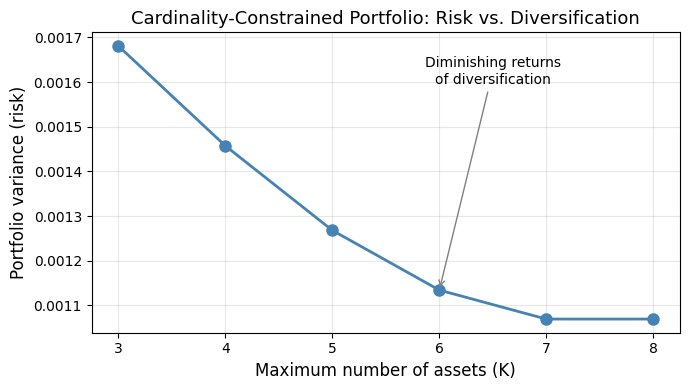

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

Ks = [r["K"] for r in results]
risks = [r["risk"] for r in results]

ax.plot(Ks, risks, "o-", color="steelblue", linewidth=2, markersize=8)
ax.set_xlabel("Maximum number of assets (K)", fontsize=12)
ax.set_ylabel("Portfolio variance (risk)", fontsize=12)
ax.set_title("Cardinality-Constrained Portfolio: Risk vs. Diversification", fontsize=13)
ax.set_xticks(Ks)
ax.grid(True, alpha=0.3)

# Annotate the diminishing returns
ax.annotate(
    "Diminishing returns\nof diversification",
    xy=(6, risks[3]),
    xytext=(6.5, risks[0] * 0.95),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="gray"),
)

plt.tight_layout()
plt.show()

### Interpretation

The plot reveals a key insight: **diversification has diminishing returns**. Going from $K=3$ to $K=4$ assets substantially reduces risk, but going from $K=7$ to $K=8$ yields almost no improvement. In practice, this means a fund manager can achieve near-optimal risk reduction with a modest number of assets, avoiding the monitoring and transaction costs of a large portfolio.

Notice also that the B&B node count varies with $K$. When $K$ is very small or very large, the problem is relatively easy (few feasible combinations, or the cardinality constraint is slack). Intermediate values of $K$ tend to be the hardest, as the solver must explore more of the search tree.

## 3. Example 2: Warehouse Selection with Quadratic Shipping Costs

A logistics company must choose which of 6 candidate warehouses to open in order to serve 10 customers. The twist: shipping costs grow **quadratically** with distance (reflecting fuel consumption, road congestion, or perishable goods degradation).

$$\min_{\text{open}, \text{alloc}} \; \sum_{i} f_i \cdot \text{open}_i + \sum_{i,j} d_{ij}^2 \cdot \text{alloc}_{ij}$$

subject to:
- $\sum_i \text{alloc}_{ij} = 1 \quad \forall j$ (each customer fully served)
- $\text{alloc}_{ij} \leq \text{open}_i \quad \forall i, j$ (only open warehouses can serve)
- $\sum_j \text{alloc}_{ij} \leq C_i \cdot \text{open}_i \quad \forall i$ (warehouse capacity)
- $\sum_i \text{open}_i \leq 3$ (budget: at most 3 warehouses)
- $\text{open}_i \in \{0, 1\}$, $\text{alloc}_{ij} \in [0, 1]$

The quadratic term $d_{ij}^2 \cdot \text{alloc}_{ij}$ makes this an MIQP rather than an MILP.

In [7]:
# Warehouse and customer locations (2D coordinates)
np.random.seed(7)
n_warehouses = 6
n_customers = 10

warehouse_pos = np.array(
    [
        [1.0, 8.0],
        [3.0, 2.0],
        [7.0, 9.0],
        [9.0, 3.0],
        [5.0, 5.0],
        [2.0, 6.0],
    ]
)
customer_pos = np.array(
    [
        [2.0, 7.0],
        [4.0, 3.0],
        [6.0, 8.0],
        [8.0, 2.0],
        [1.0, 4.0],
        [5.0, 6.0],
        [3.0, 9.0],
        [7.0, 1.0],
        [9.0, 7.0],
        [4.0, 5.0],
    ]
)

# Squared Euclidean distances
dist_sq = np.zeros((n_warehouses, n_customers))
for i in range(n_warehouses):
    for j in range(n_customers):
        diff = warehouse_pos[i] - customer_pos[j]
        dist_sq[i, j] = np.dot(diff, diff)

# Fixed costs and capacities
fixed_costs = np.array([50.0, 60.0, 45.0, 55.0, 70.0, 40.0])
capacities = np.array([4.0, 3.0, 4.0, 3.0, 5.0, 3.0])  # max customers served

print("Warehouse positions:")
for i in range(n_warehouses):
    print(
        f"  W{i}: ({warehouse_pos[i, 0]:.0f}, {warehouse_pos[i, 1]:.0f})  "
        f"cost={fixed_costs[i]:.0f}, cap={capacities[i]:.0f}"
    )
print("\nCustomer positions:")
for j in range(n_customers):
    print(f"  C{j}: ({customer_pos[j, 0]:.0f}, {customer_pos[j, 1]:.0f})")

Warehouse positions:
  W0: (1, 8)  cost=50, cap=4
  W1: (3, 2)  cost=60, cap=3
  W2: (7, 9)  cost=45, cap=4
  W3: (9, 3)  cost=55, cap=3
  W4: (5, 5)  cost=70, cap=5
  W5: (2, 6)  cost=40, cap=3

Customer positions:
  C0: (2, 7)
  C1: (4, 3)
  C2: (6, 8)
  C3: (8, 2)
  C4: (1, 4)
  C5: (5, 6)
  C6: (3, 9)
  C7: (7, 1)
  C8: (9, 7)
  C9: (4, 5)


In [8]:
m = dm.Model("warehouse_quadratic")

# Binary: open warehouse i?
open_w = m.binary("open", shape=(n_warehouses,))

# Continuous: fraction of customer j served by warehouse i
alloc = m.continuous("alloc", shape=(n_warehouses, n_customers), lb=0.0, ub=1.0)

# Objective: fixed costs + quadratic shipping
fixed_term = dm.sum(lambda i: fixed_costs[i] * open_w[i], over=range(n_warehouses))
shipping_term = dm.sum(
    lambda i: dm.sum(lambda j: dist_sq[i, j] * alloc[i, j], over=range(n_customers)),
    over=range(n_warehouses),
)
m.minimize(fixed_term + shipping_term)

# Each customer fully served
for j in range(n_customers):
    m.subject_to(dm.sum(lambda i: alloc[i, j], over=range(n_warehouses)) == 1.0, name=f"serve_{j}")

# Linking: only open warehouses can serve
for i in range(n_warehouses):
    for j in range(n_customers):
        m.subject_to(alloc[i, j] <= open_w[i], name=f"link_{i}_{j}")

# Capacity constraints
for i in range(n_warehouses):
    m.subject_to(
        dm.sum(lambda j: alloc[i, j], over=range(n_customers)) <= capacities[i] * open_w[i],
        name=f"capacity_{i}",
    )

# Budget: at most 3 warehouses
m.subject_to(dm.sum(lambda i: open_w[i], over=range(n_warehouses)) <= 3, name="budget")

result = m.solve()

print(f"Status:     {result.status}")
print(f"Objective:  {result.objective:.2f}")
print(f"Gap:        {result.gap}")
print(f"Nodes:      {result.node_count}")
print(f"Time:       {result.wall_time:.3f}s")

Using discopt IPM (pure-JAX interior point method)


Status:     optimal
Objective:  224.00
Gap:        0.0
Nodes:      11
Time:       0.972s


In [ ]:
# Display results
open_vals = result.x["open"]
alloc_vals = result.x["alloc"]

print("Warehouse decisions:")
for i in range(n_warehouses):
    status = "OPEN" if open_vals[i] > 0.5 else "closed"
    pos = warehouse_pos[i]
    print(f"  W{i} at ({pos[0]:.0f}, {pos[1]:.0f}): {status}")

print("\nCustomer assignments:")
for j in range(n_customers):
    assignments = []
    for i in range(n_warehouses):
        if alloc_vals[i, j] > 0.01:
            assignments.append(f"W{i} ({alloc_vals[i, j]:.0%})")
    pos = customer_pos[j]
    assigned = ", ".join(assignments)
    print(f"  C{j} at ({pos[0]:.0f}, {pos[1]:.0f}) -> {assigned}")

## 4. QP Relaxation in Branch and Bound

At each node of the B&B tree, the integrality constraints are dropped and the resulting **QP relaxation** is solved. For an MIQP with a convex quadratic objective ($Q \succeq 0$), each relaxation is a convex QP, which can be solved to global optimality in polynomial time.

The key insight is that the QP relaxation provides a **lower bound** on the optimal MIQP objective at that node. If the QP solution happens to be integer-feasible, the node is fathomed. Otherwise, the solver branches on a fractional integer variable, creating two child nodes.

discopt uses a specialized **QP interior-point method** (IPM) {cite:p}`Nocedal2006` implemented in JAX to solve these relaxations. The IPM exploits the QP structure (constant Hessian, linear constraints) for efficiency, and JAX's JIT compilation amortizes the cost across many B&B nodes.

### Why QP-specific solvers matter

A general-purpose NLP solver could solve each QP relaxation, but a QP-specific IPM has key advantages:

1. **Constant Hessian:** $Q$ does not change between iterations, so factorizations can be reused
2. **Warm-starting:** The QP solution at a parent node provides a good initial point for child nodes
3. **Finite convergence:** QP IPMs converge in $O(\sqrt{n})$ iterations with polynomial-time guarantees
4. **Batch solving:** With JAX's `vmap`, multiple QP relaxations can be solved in parallel {cite:p}`Boyd2004`

In [10]:
# Timing breakdown for the portfolio problem
m_timing = build_portfolio(K=5)
res_timing = m_timing.solve()

print("Solver timing breakdown:")
print(f"  Total wall time: {res_timing.wall_time:.4f}s")
print(f"  JAX time:        {res_timing.jax_time:.4f}s  (QP relaxations, autodiff)")
print(f"  Rust time:       {res_timing.rust_time:.4f}s  (B&B tree, branching, pruning)")
print(
    f"  Overhead:        {res_timing.wall_time - res_timing.jax_time - res_timing.rust_time:.4f}s"
)
print(f"\n  B&B nodes:       {res_timing.node_count}")
if res_timing.node_count > 0:
    print(f"  Time per node:   {res_timing.wall_time / res_timing.node_count * 1000:.2f}ms")

Using discopt IPM (pure-JAX interior point method)


Solver timing breakdown:
  Total wall time: 0.2096s
  JAX time:        0.2085s  (QP relaxations, autodiff)
  Rust time:       0.0003s  (B&B tree, branching, pruning)
  Overhead:        0.0008s

  B&B nodes:       137
  Time per node:   1.53ms


## 5. Exercise: Lot-Sizing with Quadratic Holding Costs

A manufacturing plant must plan production over $T = 8$ periods to meet known demand $d_t$. In each period, the plant can decide to set up production (incurring a fixed cost) and produce some quantity. Inventory is carried between periods, and **holding costs are quadratic** (reflecting deterioration, warehouse congestion, or opportunity cost that grows with inventory level).

$$\min \; \sum_{t=1}^{T} \left[ f \cdot z_t + c \cdot x_t + h \cdot I_t^2 \right]$$

subject to:
- $I_t = I_{t-1} + x_t - d_t \quad \forall t$ (inventory balance)
- $x_t \leq M \cdot z_t \quad \forall t$ (setup linking)
- $I_0 = 0$, $I_T = 0$ (no initial/final inventory)
- $z_t \in \{0, 1\}$, $x_t \geq 0$, $I_t \geq 0$

The quadratic term $h \cdot I_t^2$ makes this an MIQP. The binary variables $z_t$ represent the fixed-cost setup decision.

**Your task:** Complete the model below.

In [11]:
# Problem data
T = 8
demand = np.array([20, 30, 25, 35, 15, 40, 20, 25])
setup_cost = 100.0  # fixed cost per setup
prod_cost = 2.0  # per-unit production cost
hold_cost = 0.5  # quadratic holding cost coefficient
M_prod = float(demand.sum())  # big-M for production capacity

print(f"Periods: {T}")
print(f"Demand:  {demand}")
print(f"Total demand: {demand.sum()}")
print(f"Setup cost: {setup_cost}, Production cost: {prod_cost}/unit")
print(f"Holding cost: {hold_cost} * I^2")

# --- YOUR CODE HERE ---
# m = dm.Model("lot_sizing")
# z = m.binary("setup", shape=(T,))              # setup in period t?
# x = m.continuous("produce", shape=(T,), lb=0)   # production quantity
# I = m.continuous("inventory", shape=(T,), lb=0)  # end-of-period inventory
#
# # Objective: setup + production + quadratic holding
# m.minimize(
#     dm.sum(lambda t: setup_cost * z[t] + prod_cost * x[t] + hold_cost * I[t] * I[t],
#            over=range(T))
# )
#
# # Inventory balance: I[t] = I[t-1] + x[t] - d[t]
# m.subject_to(I[0] == x[0] - demand[0], name="inv_balance_0")  # I_{-1} = 0
# for t in range(1, T):
#     m.subject_to(I[t] == I[t - 1] + x[t] - demand[t], name=f"inv_balance_{t}")
#
# # Final inventory = 0
# m.subject_to(I[T - 1] == 0, name="final_inv")
#
# # Setup linking
# for t in range(T):
#     m.subject_to(x[t] <= M_prod * z[t], name=f"setup_link_{t}")
#
# result = m.solve()
# print(f"Objective: {result.objective:.2f}")

Periods: 8
Demand:  [20 30 25 35 15 40 20 25]
Total demand: 210
Setup cost: 100.0, Production cost: 2.0/unit
Holding cost: 0.5 * I^2


In [ ]:
# --- Solution ---
m = dm.Model("lot_sizing")
z = m.binary("setup", shape=(T,))
x = m.continuous("produce", shape=(T,), lb=0.0, ub=M_prod)
inv = m.continuous("inventory", shape=(T,), lb=0.0, ub=M_prod)

# Objective: fixed setup + linear production + quadratic holding
m.minimize(
    dm.sum(
        lambda t: setup_cost * z[t] + prod_cost * x[t] + hold_cost * inv[t] * inv[t],
        over=range(T),
    )
)

# Inventory balance: inv[t] = inv[t-1] + x[t] - d[t], with inv[-1] = 0
m.subject_to(inv[0] == x[0] - demand[0], name="inv_balance_0")
for t in range(1, T):
    m.subject_to(inv[t] == inv[t - 1] + x[t] - demand[t], name=f"inv_balance_{t}")

# Final inventory = 0
m.subject_to(inv[T - 1] == 0, name="final_inv")

# Setup linking: can only produce if setup
for t in range(T):
    m.subject_to(x[t] <= M_prod * z[t], name=f"setup_link_{t}")

result = m.solve()

print(f"Status:     {result.status}")
print(f"Objective:  {result.objective:.2f}")
print(f"Gap:        {result.gap}")
print(f"Nodes:      {result.node_count}")
print(f"Time:       {result.wall_time:.3f}s")

# Display production plan
setup_vals = result.x["setup"]
prod_vals = result.x["produce"]
inv_vals = result.x["inventory"]

print(
    f"\n{'Period':>6} {'Demand':>8} {'Setup?':>7}"
    f" {'Produce':>9} {'Inventory':>10} {'Hold Cost':>10}"
)
print("-" * 55)
for t in range(T):
    setup_flag = "Yes" if setup_vals[t] > 0.5 else "No"
    hc = hold_cost * inv_vals[t] ** 2
    print(
        f"{t + 1:6d} {demand[t]:8d} {setup_flag:>7}"
        f" {prod_vals[t]:9.1f} {inv_vals[t]:10.1f} {hc:10.2f}"
    )

## 6. Summary

In this tutorial we covered:

| Topic | Key takeaway |
|-------|-------------|
| **MIQP definition** | QP + integrality constraints; solved via B&B with QP relaxations |
| **Portfolio optimization** | Cardinality constraints turn Markowitz into MIQP; diminishing returns of diversification |
| **Warehouse selection** | Quadratic shipping costs + binary open/close decisions |
| **QP relaxation in B&B** | Convex QP at each node provides lower bound; specialized IPM solves efficiently |
| **Lot sizing** | Quadratic holding costs + fixed setup costs = classic MIQP |

### When does MIQP arise?

Look for problems that combine:
- **Quadratic costs or objectives:** variance, squared error, quadratic penalties, interaction terms
- **Discrete decisions:** select/reject, open/close, setup/no-setup, assign to groups

If the quadratic terms involve only continuous variables and $Q \succeq 0$, the QP relaxation at each B&B node is convex, making the MIQP tractable for moderate sizes. If $Q$ is indefinite, the problem becomes much harder (non-convex MIQP).

### Next steps

- **MINLP tutorial:** When constraints or objectives are nonlinear beyond quadratic, see `notebooks/minlp_examples.ipynb`
- **Advanced features:** Cutting planes, learned relaxations, and GNN branching in `notebooks/advanced_features.ipynb`
- **Differentiable optimization:** Using gradients through the solver for end-to-end learning in `notebooks/decision_focused_learning.ipynb`

### References

- {cite:p}`Markowitz1952` --- Portfolio selection and mean-variance optimization
- {cite:p}`Wolsey1998` --- Integer Programming (textbook)
- {cite:p}`Boyd2004` --- Convex Optimization (QP theory and interior-point methods)
- {cite:p}`Land1960` --- Branch and Bound algorithm
- {cite:p}`Nocedal2006` --- Numerical Optimization (IPM details)